<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/ecg-classification-resnet/blob/main/categorical_hinge_RESNET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, BatchNormalization, GlobalAveragePooling1D, Add, Input, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"  # FIXED

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (87554, 188)
Test shape: (21892, 188)


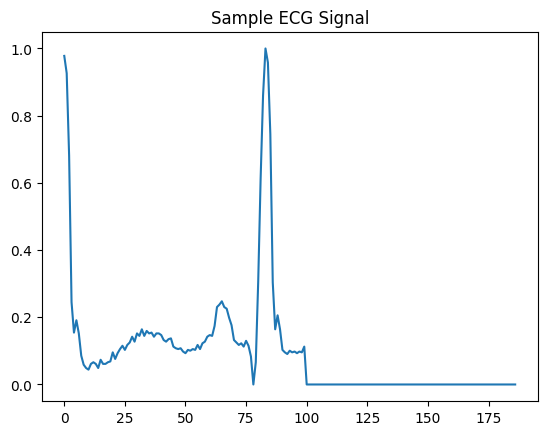

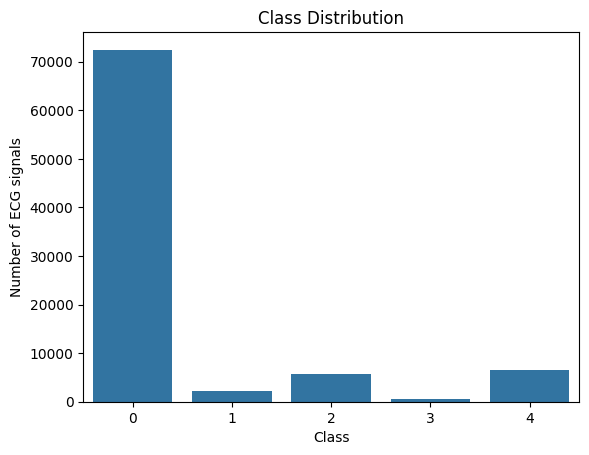

0
0


In [ ]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)
plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

print(train.isna().sum().sum())
print(test.isna().sum().sum())

In [ ]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [ ]:
X_res = np.array(X_res).reshape(-1, 187, 1)
X_test = np.array(X_test).reshape(-1, 187, 1)

In [ ]:
# Convert to one-hot
y_res_cat = to_categorical(y_res, 5)
y_test_cat = to_categorical(y_test, 5)

# Convert to -1 / +1 (required for hinge loss)
y_res_cat = 2 * y_res_cat - 1
y_test_cat = 2 * y_test_cat - 1

In [ ]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x


def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32,3,activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x,64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128,activation='relu')(x)

    # IMPORTANT: linear activation for hinge
    outputs = Dense(5, activation='linear')(x)

    model = Model(inputs,outputs)

    model.compile(
        optimizer='adam',
        loss='categorical_hinge',   # 🔥 HINGE LOSS
        metrics=['accuracy']
    )

    return model

In [ ]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [ ]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = resnet_ecg()

    model.fit(X_tr, y_tr, epochs=5, batch_size=64, verbose=1)

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)

print("\nMean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 63s 10ms/step - accuracy: 0.2004 - loss: 4.6475e-04
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.2003 - loss: 0.0000e+00
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.2003 - loss: 0.0000e+00
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.2003 - loss: 0.0000e+00
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - accuracy: 0.2003 - loss: 0.0000e+00
Fold 1 Accuracy: 0.2003

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 51s 10ms/step - accuracy: 0.2841 - loss: 4.6882e-04
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.2841 - loss: 0.0000e+00
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.2843 - loss: 0.0000e+00
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.2843 - loss: 0.0000e+00
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.2844 - loss: 0.0000e+00
Fold 2 Accuracy: 0.2848

Fold 3
Epoch

In [ ]:
model = resnet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 67s 12ms/step - accuracy: 0.3317 - loss: 5.8124e-04 - val_accuracy: 0.3319 - val_loss: 0.0000e+00
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.3317 - loss: 0.0000e+00 - val_accuracy: 0.3334 - val_loss: 0.0000e+00
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.3310 - loss: 0.0000e+00 - val_accuracy: 0.3332 - val_loss: 0.0000e+00
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.3316 - loss: 0.0000e+00 - val_accuracy: 0.3329 - val_loss: 0.0000e+00
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.3320 - loss: 0.0000e+00 - val_accuracy: 0.3339 - val_loss: 0.0000e+00
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.3312 - loss: 0.0000e+00 - val_accuracy: 0.3336 - val_loss: 0.0000e+00
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 83s 10ms/step - accuracy: 0.3312 - loss: 0.0000e+00 - val_accuracy: 0.3324 - val_loss: 0.0000e+00
Epoch 8/10
4530/4530

In [ ]:
# Convert predictions back properly
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = np.argmax((y_val_final + 1)//2, axis=1)

mcc_val = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc_val)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
Validation MCC: 0.1864184906170377


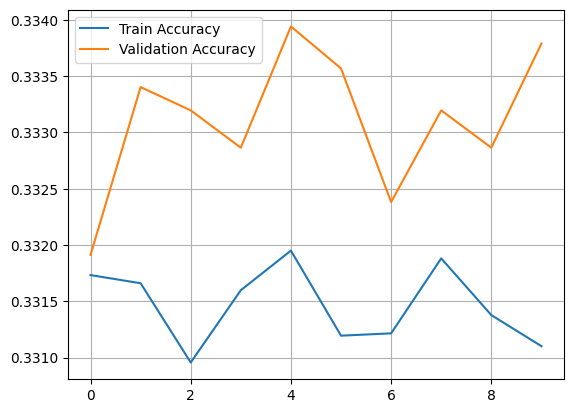

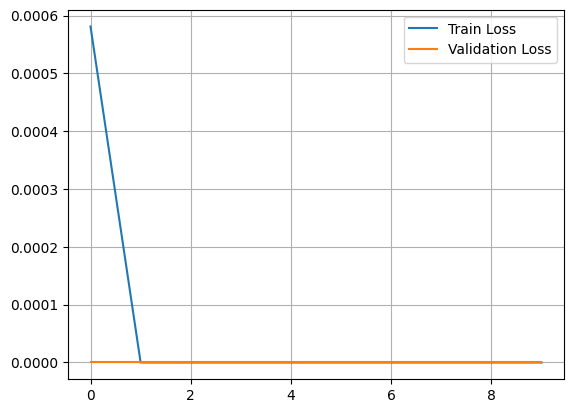

In [ ]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

y_test_pred = np.argmax(model.predict(X_test), axis=1)
y_test_true = np.argmax((y_test_cat + 1)//2, axis=1)

print(classification_report(y_test_true, y_test_pred))

Test Accuracy: 0.4875
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.94      0.51      0.66     18118
           1       0.02      0.32      0.04       556
           2       0.00      0.00      0.00      1448
           3       0.00      0.00      0.00       162
           4       0.30      0.78      0.43      1608

    accuracy                           0.49     21892
   macro avg       0.25      0.32      0.23     21892
weighted avg       0.80      0.49      0.58     21892



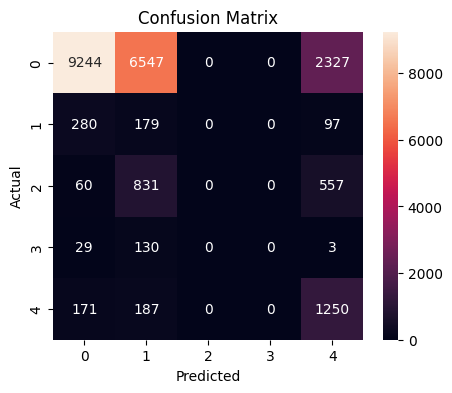

In [ ]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()